# Kepler-51 planetary system in the light of the PhotoRing effect
## Reproducing the figures of Numpaque et al. (2026)

This notebook contains the code for reproducing the figures in the paper:

> S. Numpaque, J.I. Zuluaga, D. Kipping and J.A. Alvarado "Asterodensity profile analysis of the Kepler-51 planetary system:1
a case study on the detection of exoplanetary rings via the PhotoRing effect", in preparation.

For detailed explanations see the GitHub repository: [https://github.com/seap-udea/PRisma](https://github.com/seap-udea/PRisma).

## Preparing the environment

In [1]:
# ── Bootstrap: make the repository packages importable without installation ──
import sys, pathlib
_HERE = pathlib.Path.cwd()
_cands = [_HERE, *_HERE.parents]
_REPO = next((c for c in _cands if (c / "pipeline" / "photoring").is_dir() and (c / "pipeline" / "exorings").is_dir()), _HERE.parent)
for _p in (str(_REPO / "pipeline"), str(_REPO)):
    if _p not in sys.path:
        sys.path.insert(0, _p)
print("repo root:", _REPO)


repo root: /Users/jzuluaga/dev/PRisma


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

import photoring as pr
import photoring.plotting as plot
from photoring import literature, contour
from photoring.io import load_observables, load_run
from dynesty import plotting as _dyplot

# The manuscript's look: saturated palette, LaTeX, 95% corner intervals.
plot.apply_style(plot.PAPER_STYLE)

CASE = "kepler_51"
# This notebook does not live in pipeline/, so point CasePaths at it explicitly.
paths = pr.CasePaths(CASE, pipeline_dir=_REPO / "pipeline")
IMG = pathlib.Path(_REPO / "papers" / "kepler51" / "figures")
# Posterior chains behind the manuscript figures, versioned as reference artefacts.
REFERENCE_RUNS = pathlib.Path(_REPO / "papers" / "kepler51" / "reference_runs")
IMG.mkdir(parents=True, exist_ok=True)
print("writing figures to:", IMG)

def run_version_id(files):
    """YYYYMMDDHH stamp from the newest file mtime (campaign identifier)."""
    from datetime import datetime
    files = [pathlib.Path(f) for f in files if f is not None and pathlib.Path(f).exists()]
    if not files:
        return "unknown"
    newest = max(files, key=lambda p: p.stat().st_mtime)
    return datetime.fromtimestamp(newest.stat().st_mtime).strftime("%Y%m%d%H")


def add_run_version_label(fig, version, *, x=0.988, y=0.98, fontsize=12, alpha=0.4):
    """Small vertical campaign stamp on the upper-right edge of the figure."""
    if not version or version == "unknown":
        return
    fig.text(
        x, y, str(version),
        rotation=90, va="top", ha="right",
        fontsize=fontsize, alpha=alpha, color="0.25",
        transform=fig.transFigure, clip_on=False,
    )


writing figures to: /Users/jzuluaga/dev/PRisma/papers/kepler51/figures


## 1. Configuration — the adopted runs

The manuscript's ring-geometry figures use the **fully free** model
($f_e,\ i_R,\ \theta,\ p,\ \tau,\ \rho_{\star,\rm true},\ b$ all sampled) with the likelihood
$\mathcal{L}_{\rm KDE} = (\delta,\ T_{14},\ \rho_{\star,\rm obs})$, nested sampling at
$N_{\rm live}=1200$ and $\Delta\ln Z = 0.01$, and $N_{\rm KDE}=5000$ training samples.

That combination was adopted because it is the only one in the retrieval suite that
reproduces the **full** set of transit observables — including the ones left out of the
likelihood. Simpler configurations fit their own likelihood observables but mispredict the
durations.


In [3]:
RUN_SUFFIX = ("NS_exorings_kde_delta-T14-rho_obs_nlive1200_dlogz0.01"
              "_NKDE5000_seed2026_rhoFREE_bFREE_tauFREE_pFREE")
PLANETS = ["b", "d"]

runs = {}
for pl in PLANETS:
    npz = REFERENCE_RUNS / f"{CASE}_{pl}_{RUN_SUFFIX}.npz"
    if not npz.exists():
        print(f"MISSING: {npz.name}")
        continue
    runs[pl] = load_run(npz)
    r = runs[pl]
    print(f"planet {pl}: ndim={len(r['param_names'])}  lnZ={r['logz']:.3f}  "
          f"L_KDE={r['kde_obs']}  n={len(r['chain'])}")

ttv = {pl: load_observables(paths.observables_file(pl)) for pl in PLANETS}
rho_true_samples = np.loadtxt(paths.rho_true_samples) / 1000.0   # kg/m^3 -> g/cm^3
print("\nTTV observables loaded:", {k: len(v["delta"]) for k, v in ttv.items()})

npz_used = [REFERENCE_RUNS / f"{CASE}_{pl}_{RUN_SUFFIX}.npz" for pl in PLANETS]
RUN_VERSION = run_version_id(npz_used)
print("RUN_VERSION:", RUN_VERSION)


planet b: ndim=7  lnZ=2.002  L_KDE=['delta', 'T14', 'rho_obs']  n=16631
planet d: ndim=7  lnZ=1.958  L_KDE=['delta', 'T14', 'rho_obs']  n=14994

TTV observables loaded: {'b': 17756, 'd': 39002}
RUN_VERSION: 2026073023


## 6. Inferred ring geometries

**Manuscript figures:** `final_planetb_panel_.png`, `final_planetd_panel_.png`.

Per planet: the joint posterior over ring and nuisance parameters, with a sky-plane sketch of
the inferred ring system at the posterior medians inset in the corner plot's free upper-right
triangle. The black disk is the planet, the elliptical annulus the ring.

The corner is drawn by `dynesty` from the **weighted** nested-sampling output, and the titles
report its default 95% credible interval. What to read off it:

- **$f_e$** lands well inside its uniform prior at both edges — a genuine constraint, not a
  prior artefact — and far below the prograde stability bound near $0.5\,R_{\rm Hill}$. The
  values are comparable to Saturn's main rings, which reach $\approx 2.3\,R_{\rm Saturn}$.
- **The $f_e$–$p$ anti-correlation** is the most persistent feature of the whole retrieval
  suite. The effective occulting area is $A_{\rm eff} = \pi R_p^2 + A_{\rm ring}$, so any
  $(p, f_e)$ pair preserving $A_{\rm eff}$ gives an identical transit depth and the sampler
  explores that iso-depth surface freely.
- **$i_R$ and $\theta$** favour moderately inclined rings. Because the prior on $i_R$ is
  already $\propto \sin i_R$ (isotropic, hence edge-on-favouring), any departure *from the
  prior shape* measures the information the data actually contributed.
- **$b$ and $\rho_{\star,\rm true}$** are nuisance parameters, sampled here rather than fixed.
  Their posteriors sit in tension with the external constraints, which is why the manuscript
  reports these as model-conditional geometric solutions rather than as a revision of the
  system's orbital architecture or the star's properties.


In [4]:
# ══════════════════════════════════════════════════════════════════════════
#  STYLE
# ══════════════════════════════════════════════════════════════════════════
STYLE = {
    # Typography
    "font_family": "serif",
    "font_size": 18,
    "annot_size": 12,
    "title_size": 20,
    "label_size": 18,
    "tick_size": 12,
    "legend_size": 13,
    "use_latex": False,      # True -> full LaTeX rendering (needs texlive)
    "math_font": "cm",

    # Palette (pastel astronomical)
    "c_posterior": "#A8C8E8",
    "c_data": "#808080",
    "c_prior": "#F5C5A0",
    "c_ppc_in": "#A8D8C8",
    "c_ppc_out": "#F5C5A0",
    "c_planet_b": "#A2BCCE",
    "c_planet_d": "#9AC2B8",
    "c_median": "#3D424A",
    "c_interval": "#4B5666",
    "c_accent": "#E88A6A",
    "c_corner_2d": "#7FB3D3",
    "c_corner_1d": "#6487AA",
    "c_logz": "#9CC2A5",
    "c_logl": "#E8A8A8",

    # Figure geometry
    "fig_dpi": 200,
    "fig_w_single": 3.5,
    "fig_h_single": 3.5,
    "fig_w_ppc": 4.2,
    "hspace": 0.2,
    "wspace": 0.2,

    # Lines and fills
    "hist_alpha": 0.8,
    "hist_bins": "scott",
    "hist_edgecolor": "none",
    "line_lw": 1.2,
    "line_lw_thin": 1.2,
    "spine_lw": 1.2,
    "contour_alpha": 0.85,
    "contour_smooth": 1.5,

    # Median / credible-interval markers drawn by _annotate_stats
    "median_ls": "--",
    "median_lw": 1.2,
    "median_alpha": 0.85,
    "sigma_ls": ":",
    "sigma_lw": 0.7,
    "sigma_alpha": 0.50,

    # Literature overlays (unfilled reference curves)
    "lit_lw": 1.5,
    "lit_alpha": 0.90,
    "lit_ls": "-",

    # Grid and spines
    "show_grid": True,
    "grid_alpha": 0.1,
    "grid_lw": 0.2,
    "minor_ticks": True,
    "top_spine": False,
    "right_spine": False,

    # Corner-specific
    # NOTE: dynesty's own default is the 95% interval [0.025, 0.5, 0.975]; the
    # published figures use that default (see PAPER_STYLE).
    "corner_quantiles": [0.16, 0.5, 0.84],
    "corner_levels": [0.393, 0.865],
    # Corner smoothing, as a *fraction of each parameter's plotted span* — this is
    # dynesty's own convention, and is not the same quantity as `contour_smooth`
    # (which counts bins). Values above ~0.1 wash the posterior out entirely.
    "corner_smooth": 0.02,

    # Output
    "fig_format": "png",
    "transparent": False,
}

# Default per-planet display names. Override per case with :func:`set_case_labels`.
PLANET_LABELS = {"b": "Kepler-51 b", "c": "Kepler-51 c", "d": "Kepler-51 d"}

PARAM_META = {
    "fe":       dict(label=r"$f_e\,[R_p]$", desc="Outer ring radius", symbol=r"$f_e$"),
    "ir":       dict(label=r"$i_R\,$[deg]", desc="Ring inclination", symbol=r"$i_R$"),
    "theta":    dict(label=r"$\theta\,$[deg]", desc="Ring projected tilt", symbol=r"$\theta$"),
    "p":        dict(label=r"$p=R_p/R_\star$", desc="Planet radius ratio", symbol=r"$p$"),
    "tau":      dict(label=r"$\tau$", desc="Ring opacity", symbol=r"$\tau$"),
    "rho_true": dict(label=r"$\rho_{\star,\rm true}\,$[g/cm$^3$]",
                     desc="True stellar density", symbol=r"$\rho_{\star,\rm true}$"),
    "b":        dict(label=r"$b$", desc="Impact parameter", symbol=r"$b$"),
}

def param_meta(name):
    """Metadata for a model-parameter name, falling back to the bare name."""
    return PARAM_META.get(name, dict(label=name, desc=name, symbol=name))

#: Fallback cycle for cases with more planets than the palette names explicitly.
_PLANET_COLOR_CYCLE = ["#A6CEE8", "#90DBC7", "#F5C5A0", "#C8B0E8", "#E8C8B0"]
_PLANET_LINE_CYCLE = ["#0072B2", "#009E73", "#C17D11", "#6A3D9A", "#8B4513"]

OBS_META = {
    "delta": dict(
        df_col="delta", ppc_col=0, scale=1e6, unit="ppm",
        symbol=r"$\delta$", label=r"$\delta$ [ppm]",
        xlabel=r"Transit depth $\delta$ [ppm]", short="Transit depth"),
    "T14": dict(
        df_col="T14", ppc_col=1, scale=1.0, unit="h",
        symbol=r"$T_{14}$", label=r"$T_{14}$ [h]",
        xlabel=r"Total duration $T_{14}$ [h]", short="Total duration"),
    "T23": dict(
        df_col="T23", ppc_col=2, scale=1.0, unit="h",
        symbol=r"$T_{23}$", label=r"$T_{23}$ [h]",
        xlabel=r"Flat duration $T_{23}$ [h]", short="Flat duration"),
    "rho_obs": dict(
        df_col="rho_obs_gcc", ppc_col=3, scale=1.0, unit=r"g cm$^{-3}$",
        symbol=r"$\rho_{\star,\rm obs}$",
        label=r"$\rho_{\star,\rm obs}$ [g cm$^{-3}$]",
        xlabel=r"Stellar density $\rho_{\star,\rm obs}$ [g cm$^{-3}$]",
        short="Obs. density"),
    "b_obs": dict(
        df_col="b", ppc_col=4, scale=1.0, unit="",
        symbol=r"$b_{\rm obs}$", label=r"$b_{\rm obs}$",
        xlabel=r"Impact parameter $b_{\rm obs}$", short="Impact parameter"),
    "aR": dict(
        df_col="aR", ppc_col=None, scale=1.0, unit="",
        symbol=r"$a/R_{\star}$", label=r"$a/R_{\star}$",
        xlabel=r"Scaled semimajor axis $a/R_{\star}$", short="Scaled semimajor axis"),
}

def obs_meta(key):
    """Metadata for an observable key, with a clear error for unknown keys."""
    try:
        return OBS_META[key]
    except KeyError:
        raise KeyError(
            f"Unknown observable {key!r}. Known keys: {sorted(OBS_META)}") from None

def planet_color(planet, kind="fill"):
    """Palette colour for a planet key.

    ``kind`` selects ``"fill"`` (histograms, ring patches), ``"line"`` (KDE curves,
    median markers) or ``"corner"`` (corner-plot ink). Planets beyond those named in
    :data:`STYLE` fall back to a deterministic cycle keyed on the planet letter, so a
    case with more than two planets still gets stable, distinct colours.
    """
    prefix = "c_corner_" if kind == "corner" else "c_planet_"
    suffix = "_line" if kind == "line" else ""
    explicit = STYLE.get(f"{prefix}{planet}{suffix}")
    if explicit:
        return explicit
    # "corner"/"line" not declared for this planet -> fall back to its fill colour.
    if kind != "fill":
        fallback = STYLE.get(f"c_planet_{planet}")
        if fallback:
            return fallback

    # Unnamed planet: take the next cycle entry not already claimed by an explicit
    # STYLE colour, so a third planet never collides with b's or d's colour.
    cycle = _PLANET_LINE_CYCLE if kind == "line" else _PLANET_COLOR_CYCLE
    claimed = {v for k, v in STYLE.items()
               if k.startswith("c_planet_") and isinstance(v, str)}
    free = [c for c in cycle if c not in claimed] or cycle
    unnamed = [p for p in sorted(PLANET_LABELS) if not STYLE.get(f"c_planet_{p}")]
    idx = unnamed.index(planet) if planet in unnamed else 0
    return free[idx % len(free)]


# ══════════════════════════════════════════════════════════════════════════
#  Corner plot
# ══════════════════════════════════════════════════════════════════════════
def plot_corner(run, paths=None, ax_grid=None, title=True, save=True):
    """Joint-posterior corner plot, drawn by ``dynesty.plotting.cornerplot``.

    dynesty is the only backend: it works from the *weighted* nested-sampling output
    (``samples`` + ``logwt``), which is the posterior the sampler actually produced. The
    equal-weight ``chain`` is a resampled view of it, so a corner drawn from ``chain``
    with a different library gives subtly different contours and quantiles.

    The reported credible interval follows ``STYLE["corner_quantiles"]``; dynesty's own
    default (and the one the published figures use, see :data:`PAPER_STYLE`) is the 95%
    interval ``[0.025, 0.5, 0.975]``.

    Parameters
    ----------
    ax_grid : ndarray of Axes, optional
        Existing ``(ndim, ndim)`` axes grid to draw into, e.g. to compose the corner
        with other panels in one figure.
    title : bool
        Add a suptitle. Pass ``False`` when embedding the corner in a larger panel that
        carries its own title.
    """
    labels = [param_meta(n)["label"] for n in run["param_names"]]
    kwargs = dict(
        labels=labels, show_titles=True,
        title_kwargs={"fontsize": STYLE["tick_size"] + 10},
        # span_kwargs={'labelsize': STYLE["tick_size"]},   # Tamaño de ticks en gráficos 2D
        # hist_kwargs={'labelsize': STYLE["tick_size"]},   # Tamaño de ticks en histogramas 1D
        # label_kwargs={'labelsize': STYLE["label_size"]},    # Tamaño de los nombres de los parámetros
        quantiles=STYLE["corner_quantiles"],
        color=planet_color(run["planet"], "corner"),
        smooth=STYLE["corner_smooth"],
    )
    if ax_grid is not None:
        # dynesty takes an existing grid as a (figure, axes) tuple.
        kwargs["fig"] = (ax_grid[0, 0].get_figure(), ax_grid)
    fig, _axes = _dyplot.cornerplot(run["dres"], **kwargs)

    # Cambiar tamaño de los ticks en todos los subgráficos
    for ax in _axes.flatten():
        if ax is not None:
            ax.tick_params(axis='both', which='major', labelsize=STYLE['label_size'] + 5)
            ax.xaxis.label.set_size(STYLE['label_size'] + 5)
            ax.yaxis.label.set_size(STYLE['label_size'] + 5)

    if title:
        planet_label = PLANET_LABELS.get(run["planet"], run["planet"])
        fig.suptitle(f"Joint posteriors — {planet_label}",
                     fontsize=STYLE["title_size"] + 5, y=1.01)
    if save:
        _save(fig, f"{run['tag']}_corner", paths, "corner")
    return fig, _axes


# ══════════════════════════════════════════════════════════════════════════
#  Ring-diagram median values (shared with plot_ring_diagram)
# ══════════════════════════════════════════════════════════════════════════
def _get_ring_diagram_values(run):
    """Extract the median ring-diagram parameter values from a run.

    Returns a dict with keys 'fe', 'ir', 'theta', 'p' — the same values
    that :func:`plot_ring_diagram` uses to draw the projected ring system.
    """
    chain = run["chain"]; pnames = run["param_names"]; meta = run["meta"]

    def _get(name, default):
        return chain[:, pnames.index(name)] if name in pnames else np.full(len(chain), default)

    return dict(
        fe    = float(np.median(_get("fe",    meta.get("FE_MAX", 5.0) / 2))),
        ir    = float(np.median(_get("ir",    45.0))),
        theta = float(np.median(_get("theta", 90.0))),
        p     = float(np.median(_get("p",     meta.get("p_mean_ref", 0.08)))),
        tau   = float(np.median(_get("tau",   0.5))),
    )


# ══════════════════════════════════════════════════════════════════════════
#  Ring geometry diagram
# ══════════════════════════════════════════════════════════════════════════
def plot_ring_diagram(run, ax=None, paths=None, scale=0.2, dx=0.0):
    """Draw the median-posterior ring geometry projected onto the stellar disk.

    Uses :mod:`geotrans` (``RingedSystem`` + ``plotEllipse``) to render the ellipses.
    """
    import geotrans as gt2
    meta = run["meta"]
    ring_vals = _get_ring_diagram_values(run)
    fe    = ring_vals["fe"]
    ir    = ring_vals["ir"]
    theta = ring_vals["theta"]
    p     = ring_vals["p"]
    tau   = ring_vals["tau"]
    fi    = meta.get("FI_FIXED", 1.0)

    own_fig = ax is None
    if own_fig:
        fig = plt.figure(figsize=(3, 3)); ax = fig.add_subplot(111)
    else:
        fig = ax.get_figure()
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_axis_off()
    ax.set_aspect("equal", adjustable="box")

    col = planet_color(run["planet"])
    System = gt2.RingedSystem(dict(fe=fe, ir=ir, theta=theta, p=p, fi=fi))
    fh = scale / (System.fe * System.Rp); fv = fh
    C = np.array([0.5 + dx, 0.5])
    Planet = gt2.Figure(C, fh * System.Rp, fv * System.Rp, 1.0, 0.0, "Planet")
    Ringe = gt2.Figure(C, fh * System.Re, fv * System.Re * np.cos(System.ir),
                       np.cos(System.phir), np.sin(System.phir), "Ringext")
    Ringi = gt2.Figure(C, fh * System.Ri, fv * System.Ri * np.cos(System.ir),
                       np.cos(System.phir), np.sin(System.phir), "Ringint")
    gt2.plotEllipse(ax, Planet, patch=True, zorder=10, color="k", transform=ax.transAxes)
    gt2.plotEllipse(ax, Ringe, zorder=9, color=col, alpha=0.85,
                    lw=STYLE["line_lw"], transform=ax.transAxes)
    gt2.plotEllipse(ax, Ringi, zorder=9, color=col, alpha=0.30,
                    lw=STYLE["line_lw_thin"], transform=ax.transAxes)

    label_text1 = f"$f_e={fe:.2f}$, $i_R={ir:.1f}^\\circ$, $\\theta={theta:.1f}^\\circ$, $p={p:.3f}$, $\\tau={tau:.2f}$"
    #label_text2 = f""
    fontsize = STYLE["tick_size"] + 10
    ax.text(0.5 + dx, 0.15, label_text1, ha="center", va="top", transform=ax.transAxes, fontsize=fontsize, color="black")
    #ax.text(0.5 + dx, 0.05, label_text2, ha="center", va="top", transform=ax.transAxes, fontsize=fontsize, color="black")

    if own_fig:
        _save(fig, f"{run['tag']}_ring", paths, "ring")
    return fig

def plot_results_panel_inset(run, paths=None, ring_frac=None, pad=0.01,
                             run_tag_suffix="panel_inset", title=True):
    """Square corner plot with the inferred ring geometry inset in the upper-right.

    This is the per-planet summary figure: the joint posterior over ring and nuisance
    parameters, plus — drawn in the empty upper-right triangle that a corner plot always
    leaves free — a sky-plane sketch of the ring system at the posterior medians.

    Unlike :func:`plot_results_panel`, the corner is rendered **live** by
    :func:`plot_corner` rather than re-read from a saved PNG, so the result stays
    resolution-independent and needs no image post-processing.

    Parameters
    ----------
    ring_frac : float, optional
        Side of the inset as a fraction of the figure. Defaults to
        ``min(0.2 + 0.025 * ndim, 0.40)``, which keeps the sketch inside the free
        triangle as the number of parameters grows.
    """
    ndim = len(run["param_names"])
    fig, _axes = plot_corner(run, paths=None, title=False, save=False)
    if fig is None:
        return None

    # --- Overlay red dots for ring-diagram median values on the 2D cells ---
    ring_vals = _get_ring_diagram_values(run)
    pnames = list(run["param_names"])
    # For every pair (col_idx < row_idx) that are both ring-diagram parameters,
    # plot a red dot at (ring_vals[pnames[col_idx]], ring_vals[pnames[row_idx]])
    # in the 2D cell _axes[row_idx, col_idx]  (lower triangle).
    for col_idx in range(ndim):
        px = pnames[col_idx]
        if px not in ring_vals:
            continue
        for row_idx in range(col_idx + 1, ndim):
            py = pnames[row_idx]
            if py not in ring_vals:
                continue
            ax = _axes[row_idx, col_idx]
            if ax is not None:
                ax.plot(ring_vals[px], ring_vals[py],
                        'o', color='red', ms=8, mew=1.5,
                        mec='darkred', zorder=100)
    # Also mark values on the 1D diagonal histograms with vertical red lines
    for idx in range(ndim):
        pname = pnames[idx]
        if pname in ring_vals:
            ax = _axes[idx, idx]
            if ax is not None:
                ax.axvline(ring_vals[pname], color='red', ls='-',
                           lw=1.5, alpha=0.9, zorder=100)

    side = ndim * STYLE["fig_w_single"] * 1.05
    fig.set_size_inches(side, side)
    fig.set_dpi(STYLE["fig_dpi"])

    frac = ring_frac if ring_frac is not None else min(0.2 + 0.025 * ndim, 0.40)
    ax_ring = fig.add_axes([1.0 - frac - pad, 1.0 - frac - pad, frac, frac])
    ax_ring.set_axis_off()
    try:
        plot_ring_diagram(run, ax=ax_ring)
    except Exception as e:
        ax_ring.text(0.5, 0.5, f"Ring diagram\nunavailable\n({e})", ha="center",
                     va="center", color="gray", fontsize=STYLE["annot_size"] + 2,
                     transform=ax_ring.transAxes)

    if title:
        planet_label = PLANET_LABELS.get(run["planet"], run["planet"])
        fig.suptitle(f"\n{planet_label} — Posterior results\n\n{_run_title(run)}\n",
                     fontsize=STYLE["title_size"] + 5, y=0.98)

    return fig

def _run_title(run):
    r"""``L_KDE: [obs…]   \hat{theta}: [params…]`` — which data constrained which parameters."""
    kde_symbols = r" \; ".join(obs_meta(k)["symbol"].replace("$", "")
                               for k in run["kde_obs"])
    par_symbols = r" \; ".join(param_meta(p)["symbol"].replace("$", "")
                               for p in run["param_names"])
    params = []
    etas = []
    qeta = False
    for p in run["param_names"]:
        if 'true' in param_meta(p)["symbol"]:
            qeta = True
        if not qeta:
            params += [param_meta(p)["symbol"].replace("$", "")]
        if qeta:
            etas += [param_meta(p)["symbol"].replace("$", "")]
    par_symbols = r" \; ".join(params)
    eta_symbols = r" \; ".join(etas)

    return (rf"$\mathcal{{L}}_{{\mathrm{{KDE}}}}\text{{: }}"
            rf"\left[ {kde_symbols} \right]"
            rf" \qquad \boldsymbol{{{{\theta}}}}\text{{: }}"
            rf"\left[ {par_symbols} \right]"
            rf" \qquad \boldsymbol{{{{\eta}}}}\text{{: }}"
            rf"\left[ {eta_symbols} \right]"
            rf"$"
            )


-> /Users/jzuluaga/dev/PRisma/papers/kepler51/figures/final_planetb_panel_.png


-> /Users/jzuluaga/dev/PRisma/papers/kepler51/figures/final_planetd_panel_.png


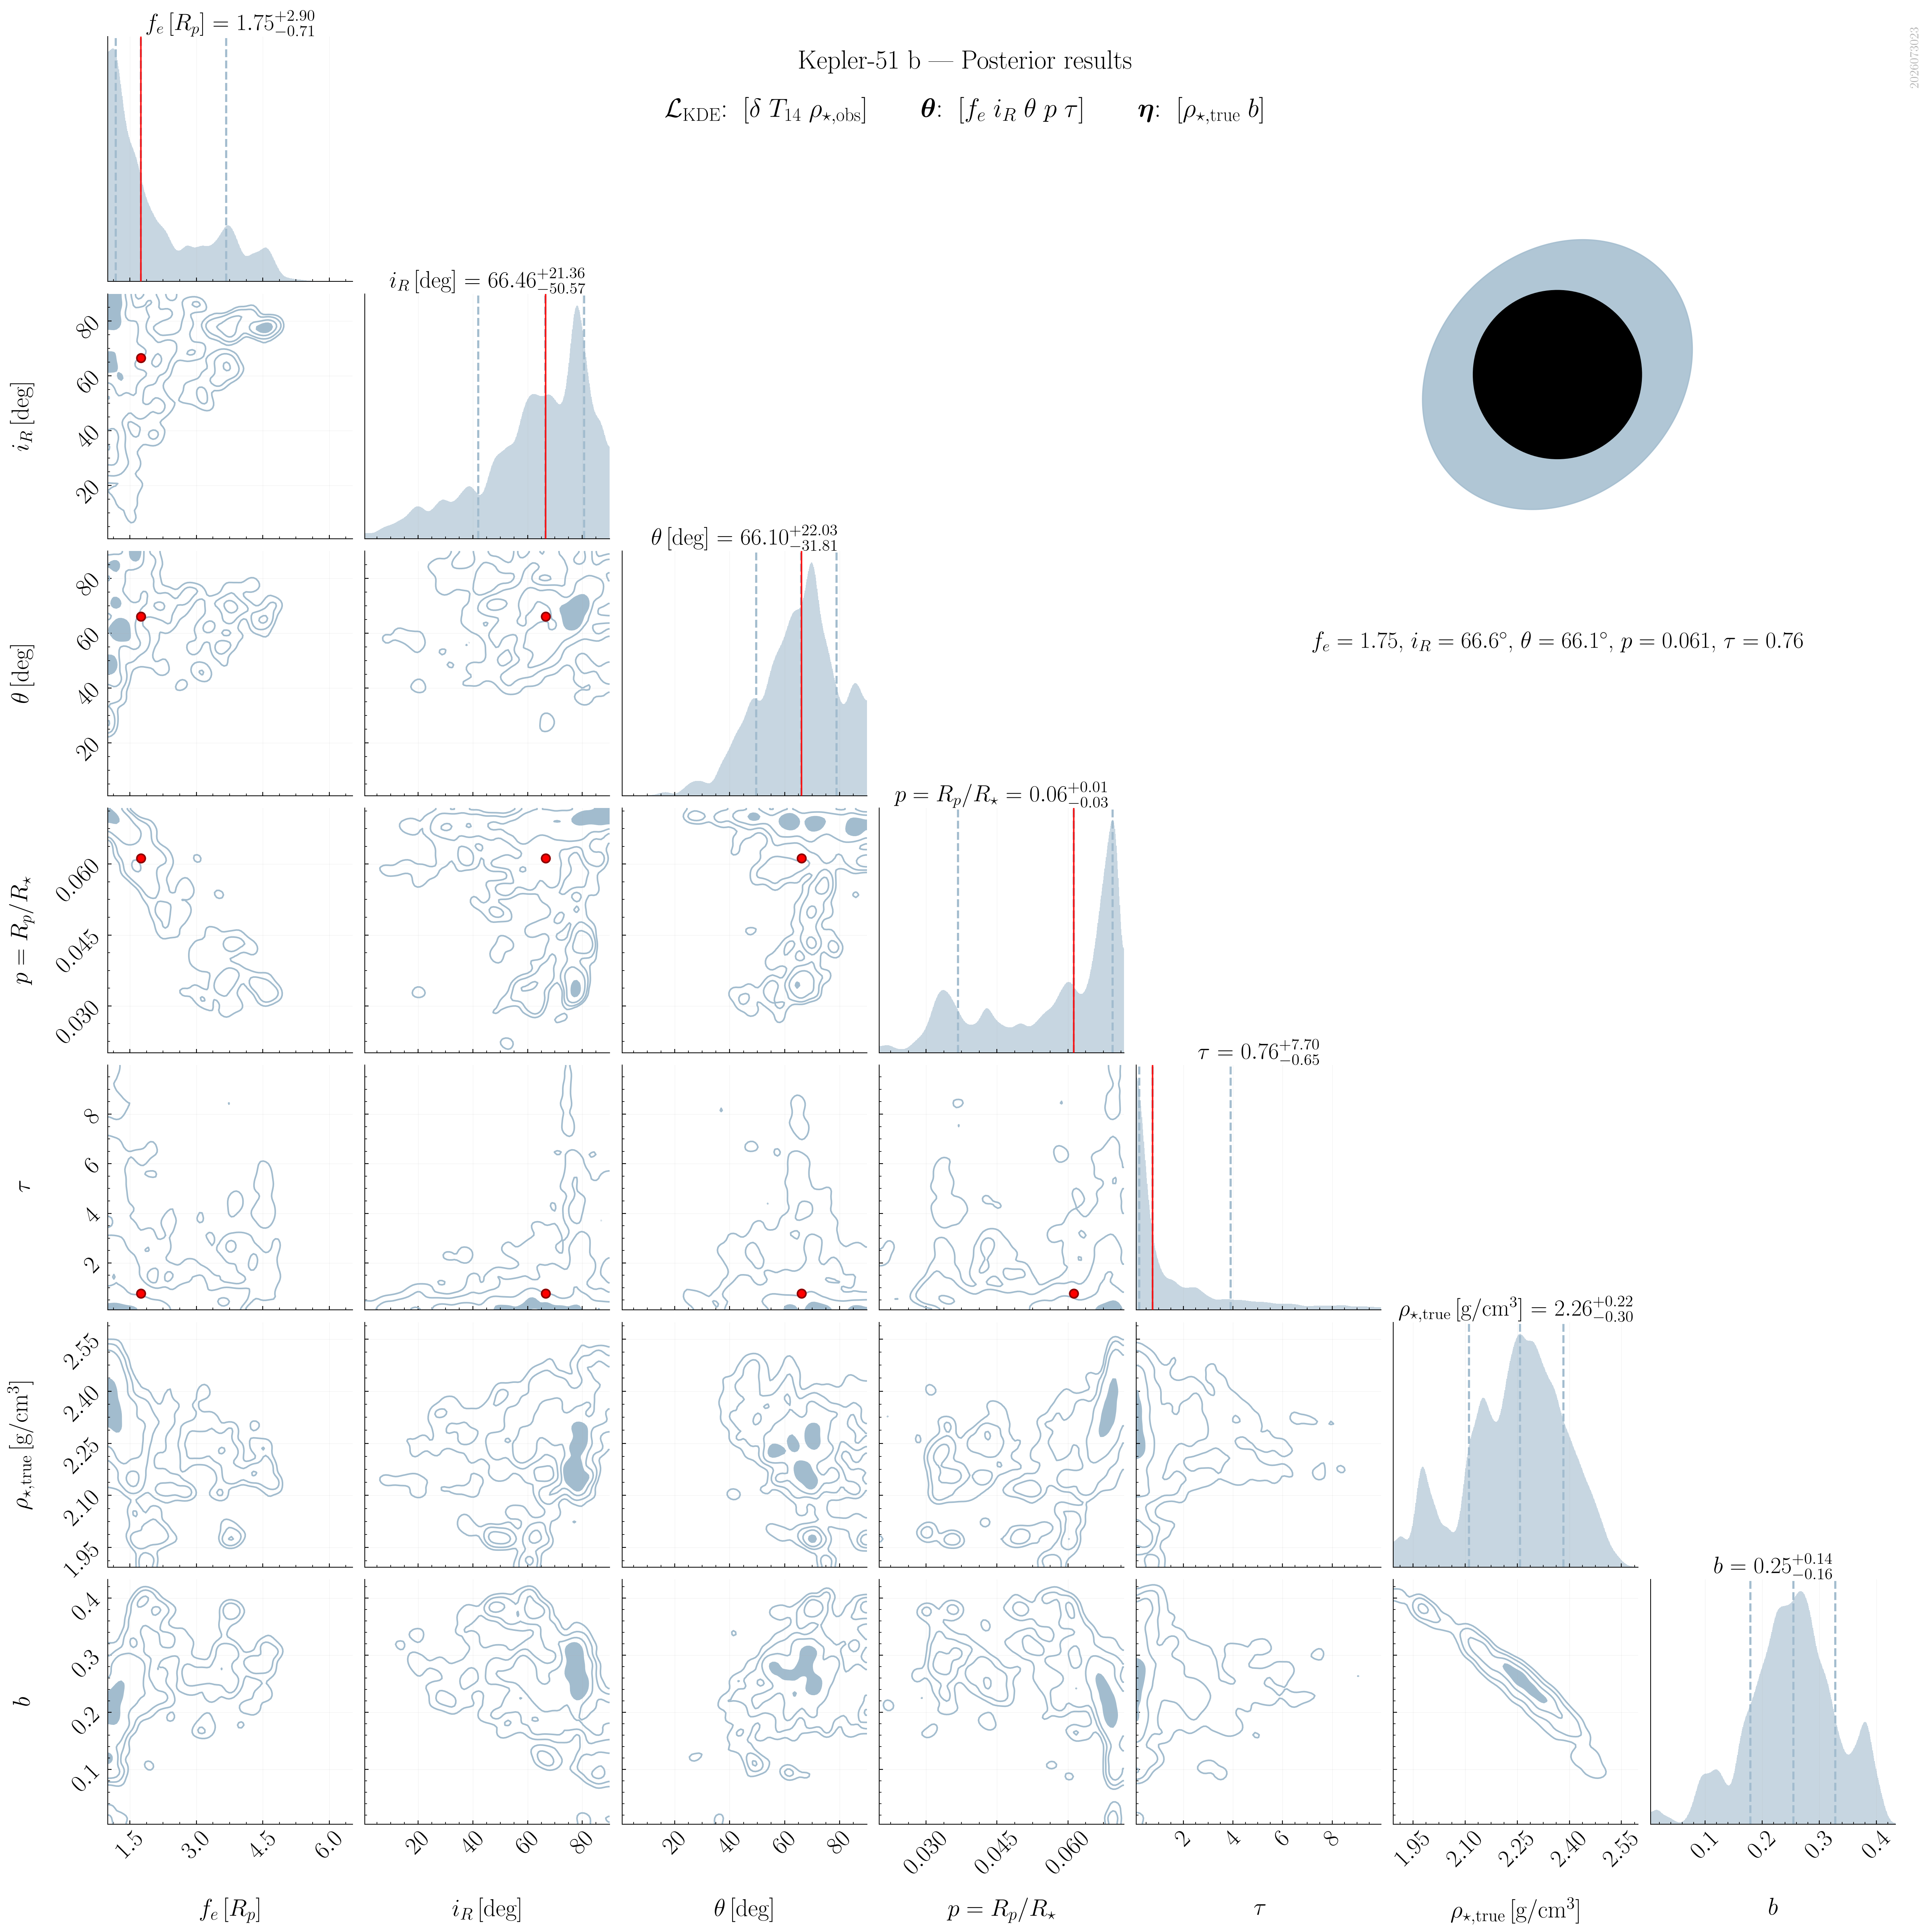

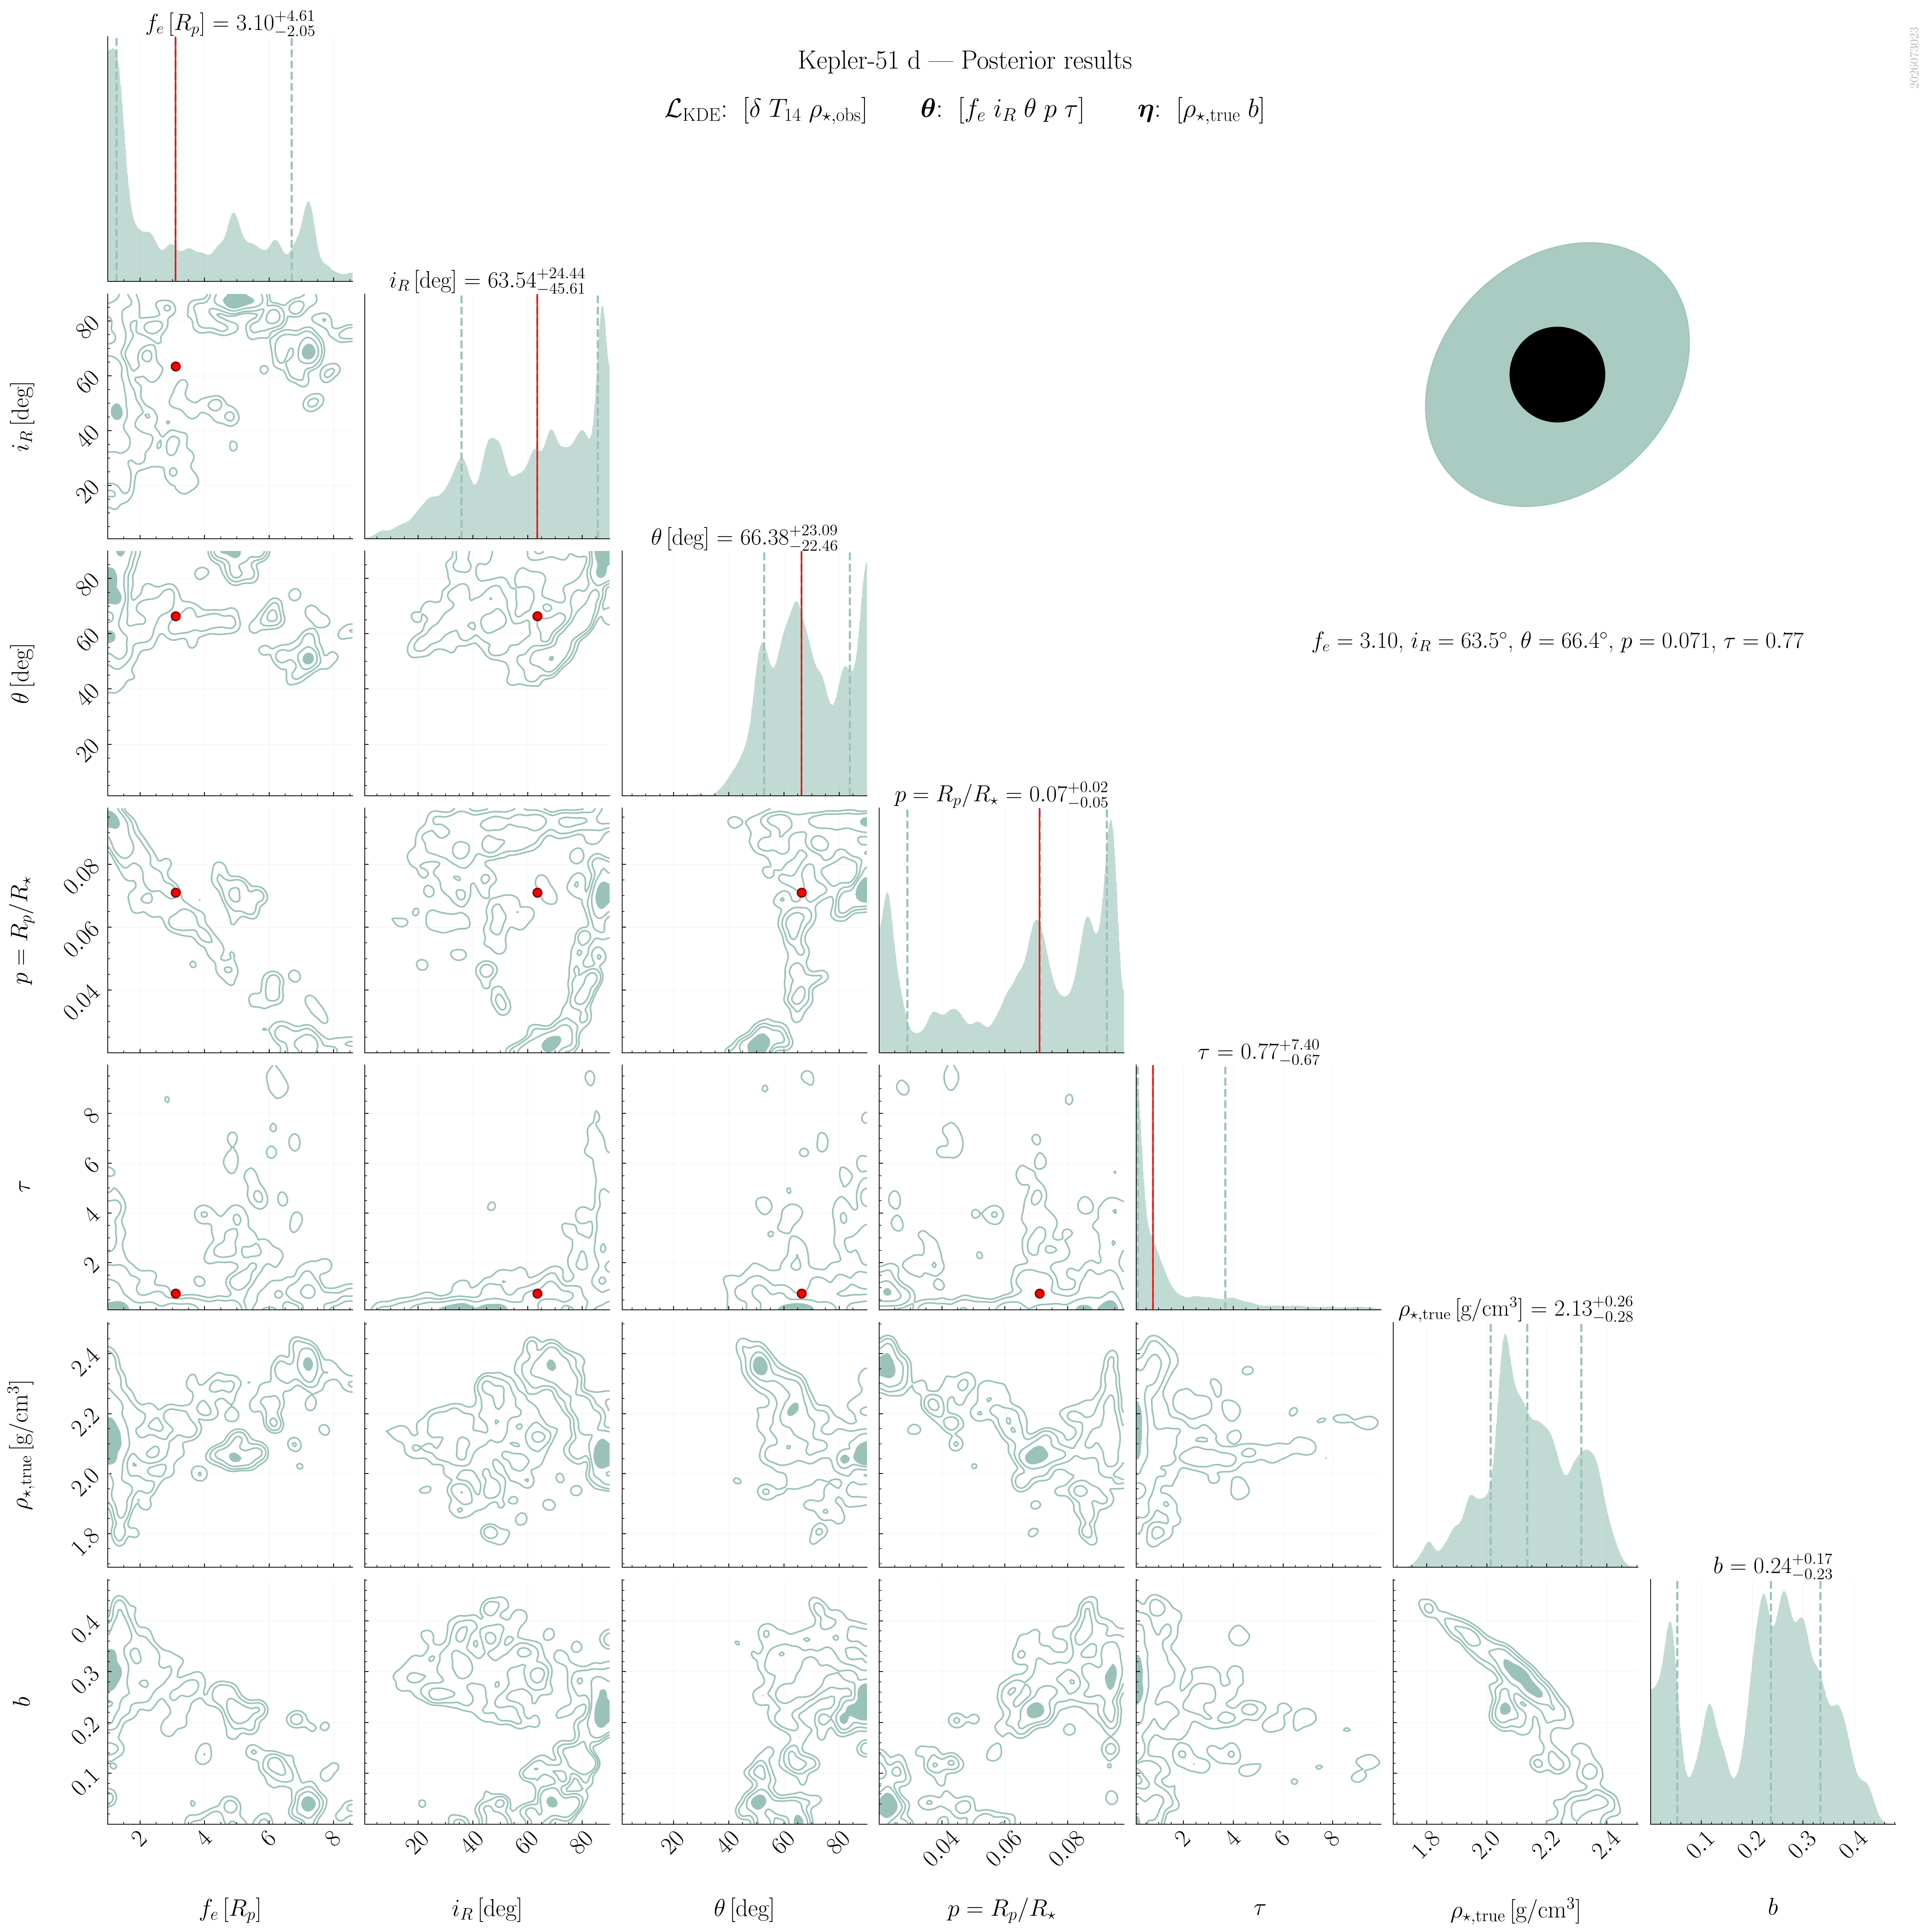

In [5]:
PANEL_NAME = {"b": "final_planetb_panel_.png", "d": "final_planetd_panel_.png"}

for pl, run in runs.items():
    fig = plot_results_panel_inset(run)
    out = IMG / PANEL_NAME[pl]
    add_run_version_label(fig, RUN_VERSION)
    fig.savefig(out, dpi=plot.STYLE["fig_dpi"], bbox_inches="tight")
    print("->", out)
    # break
    # plt.close(fig)


### Reduced Corner Plots
This section contains routines to plot the corner plots excluding nuisance parameters $\rho_{\star,\text{true}}$ and $b$.

In [6]:
def plot_corner_reduced(run, paths=None, ax_grid=None, title=True, save=True):
    pnames = run["param_names"]
    
    # Identify indices of parameters to keep (exclude rho_star_true and b)
    dims = [i for i, p in enumerate(pnames) if "rho" not in p and p != "b"]
    plotted_pnames = [pnames[i] for i in dims]
    labels = [param_meta(p)["label"] for p in plotted_pnames]
    
    kwargs = dict(
        labels=labels, show_titles=True,
        title_kwargs={"fontsize": STYLE["tick_size"] + 10},
        quantiles=STYLE["corner_quantiles"],
        color=planet_color(run["planet"], "corner"),
        smooth=STYLE["corner_smooth"],
        dims=dims
    )
    if ax_grid is not None:
        kwargs["fig"] = (ax_grid[0, 0].get_figure(), ax_grid)
    fig, _axes = _dyplot.cornerplot(run["dres"], **kwargs)

    for ax in _axes.flatten():
        if ax is not None:
            ax.tick_params(axis='both', which='major', labelsize=STYLE['label_size'] + 5)
            ax.xaxis.label.set_size(STYLE['label_size'] + 5)
            ax.yaxis.label.set_size(STYLE['label_size'] + 5)

    if title:
        planet_label = PLANET_LABELS.get(run["planet"], run["planet"])
        fig.suptitle(f"Joint posteriors — {planet_label}",
                     fontsize=STYLE["title_size"] + 5, y=1.01)
    if save:
        _save(fig, f"{run['tag']}_corner_reduced", paths, "corner_reduced")
    return fig, _axes, plotted_pnames

def plot_results_panel_reduced_inset(run, paths=None, ring_frac=None, pad=0.01,
                             run_tag_suffix="panel_inset_reduced", title=True):
    fig, _axes, plotted_pnames = plot_corner_reduced(run, paths=None, title=False, save=False)
    if fig is None:
        return None

    ndim = len(plotted_pnames)
    ring_vals = _get_ring_diagram_values(run)
    
    for col_idx in range(ndim):
        px = plotted_pnames[col_idx]
        if px not in ring_vals:
            continue
        for row_idx in range(col_idx + 1, ndim):
            py = plotted_pnames[row_idx]
            if py not in ring_vals:
                continue
            ax = _axes[row_idx, col_idx]
            if ax is not None:
                ax.plot(ring_vals[px], ring_vals[py],
                        'o', color='red', ms=8, mew=1.5,
                        mec='darkred', zorder=100)
                        
    for idx in range(ndim):
        pname = plotted_pnames[idx]
        if pname in ring_vals:
            ax = _axes[idx, idx]
            if ax is not None:
                ax.axvline(ring_vals[pname], color='red', ls='-',
                           lw=1.5, alpha=0.9, zorder=100)

    side = ndim * STYLE["fig_w_single"] * 1.05
    fig.set_size_inches(side, side)
    fig.set_dpi(STYLE["fig_dpi"])

    frac = ring_frac if ring_frac is not None else min(0.2 + 0.025 * ndim, 0.40)
    ax_ring = fig.add_axes([1.0 - frac - pad, 1.0 - frac - pad, frac, frac])
    ax_ring.set_axis_off()
    try:
        plot_ring_diagram(run, ax=ax_ring, dx=-0.15)
    except Exception as e:
        ax_ring.text(0.5, 0.5, f"Ring diagram\nunavailable\n({e})", ha="center",
                     va="center", color="gray", fontsize=STYLE["annot_size"] + 2,
                     transform=ax_ring.transAxes)

    if title:
        planet_label = PLANET_LABELS.get(run["planet"], run["planet"])
        fig.suptitle(f"\n{planet_label} — Posterior results\n\n{_run_title(run)}\n",
                     fontsize=STYLE["title_size"] + 5, y=0.98)

    return fig


-> /Users/jzuluaga/dev/PRisma/papers/kepler51/figures/final_planetb_panel_reduced.png


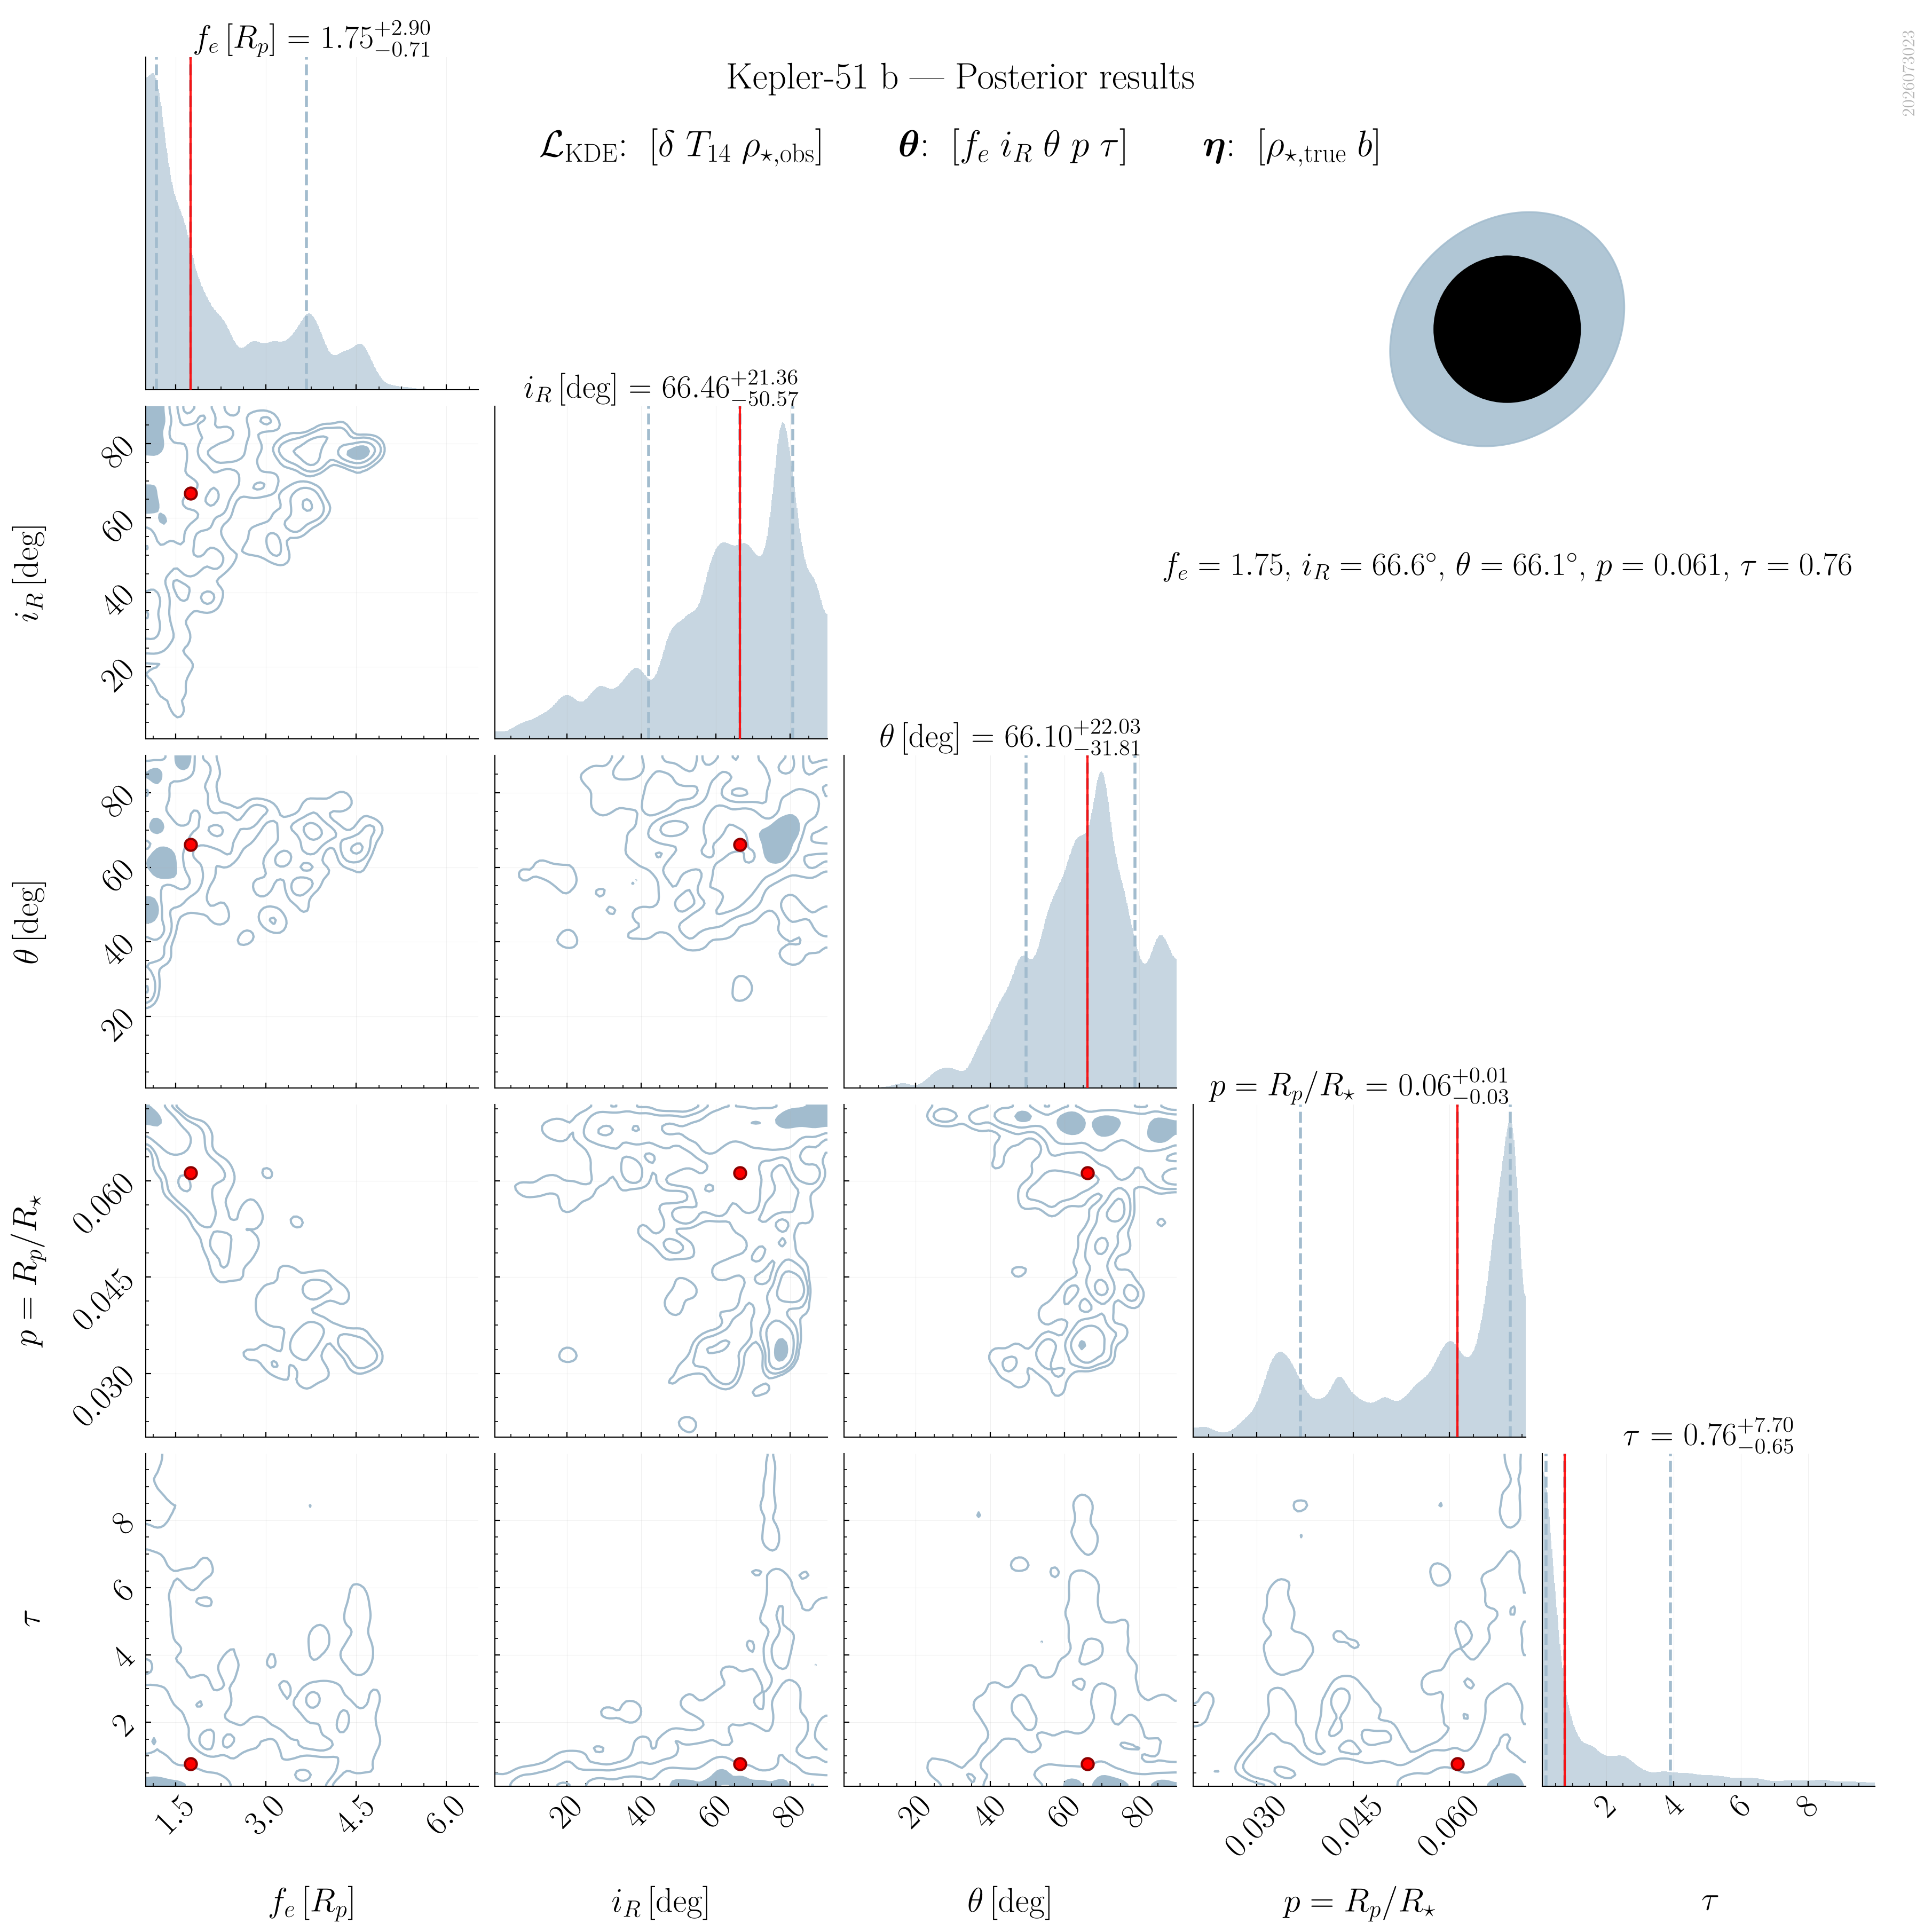

-> /Users/jzuluaga/dev/PRisma/papers/kepler51/figures/final_planetd_panel_reduced.png


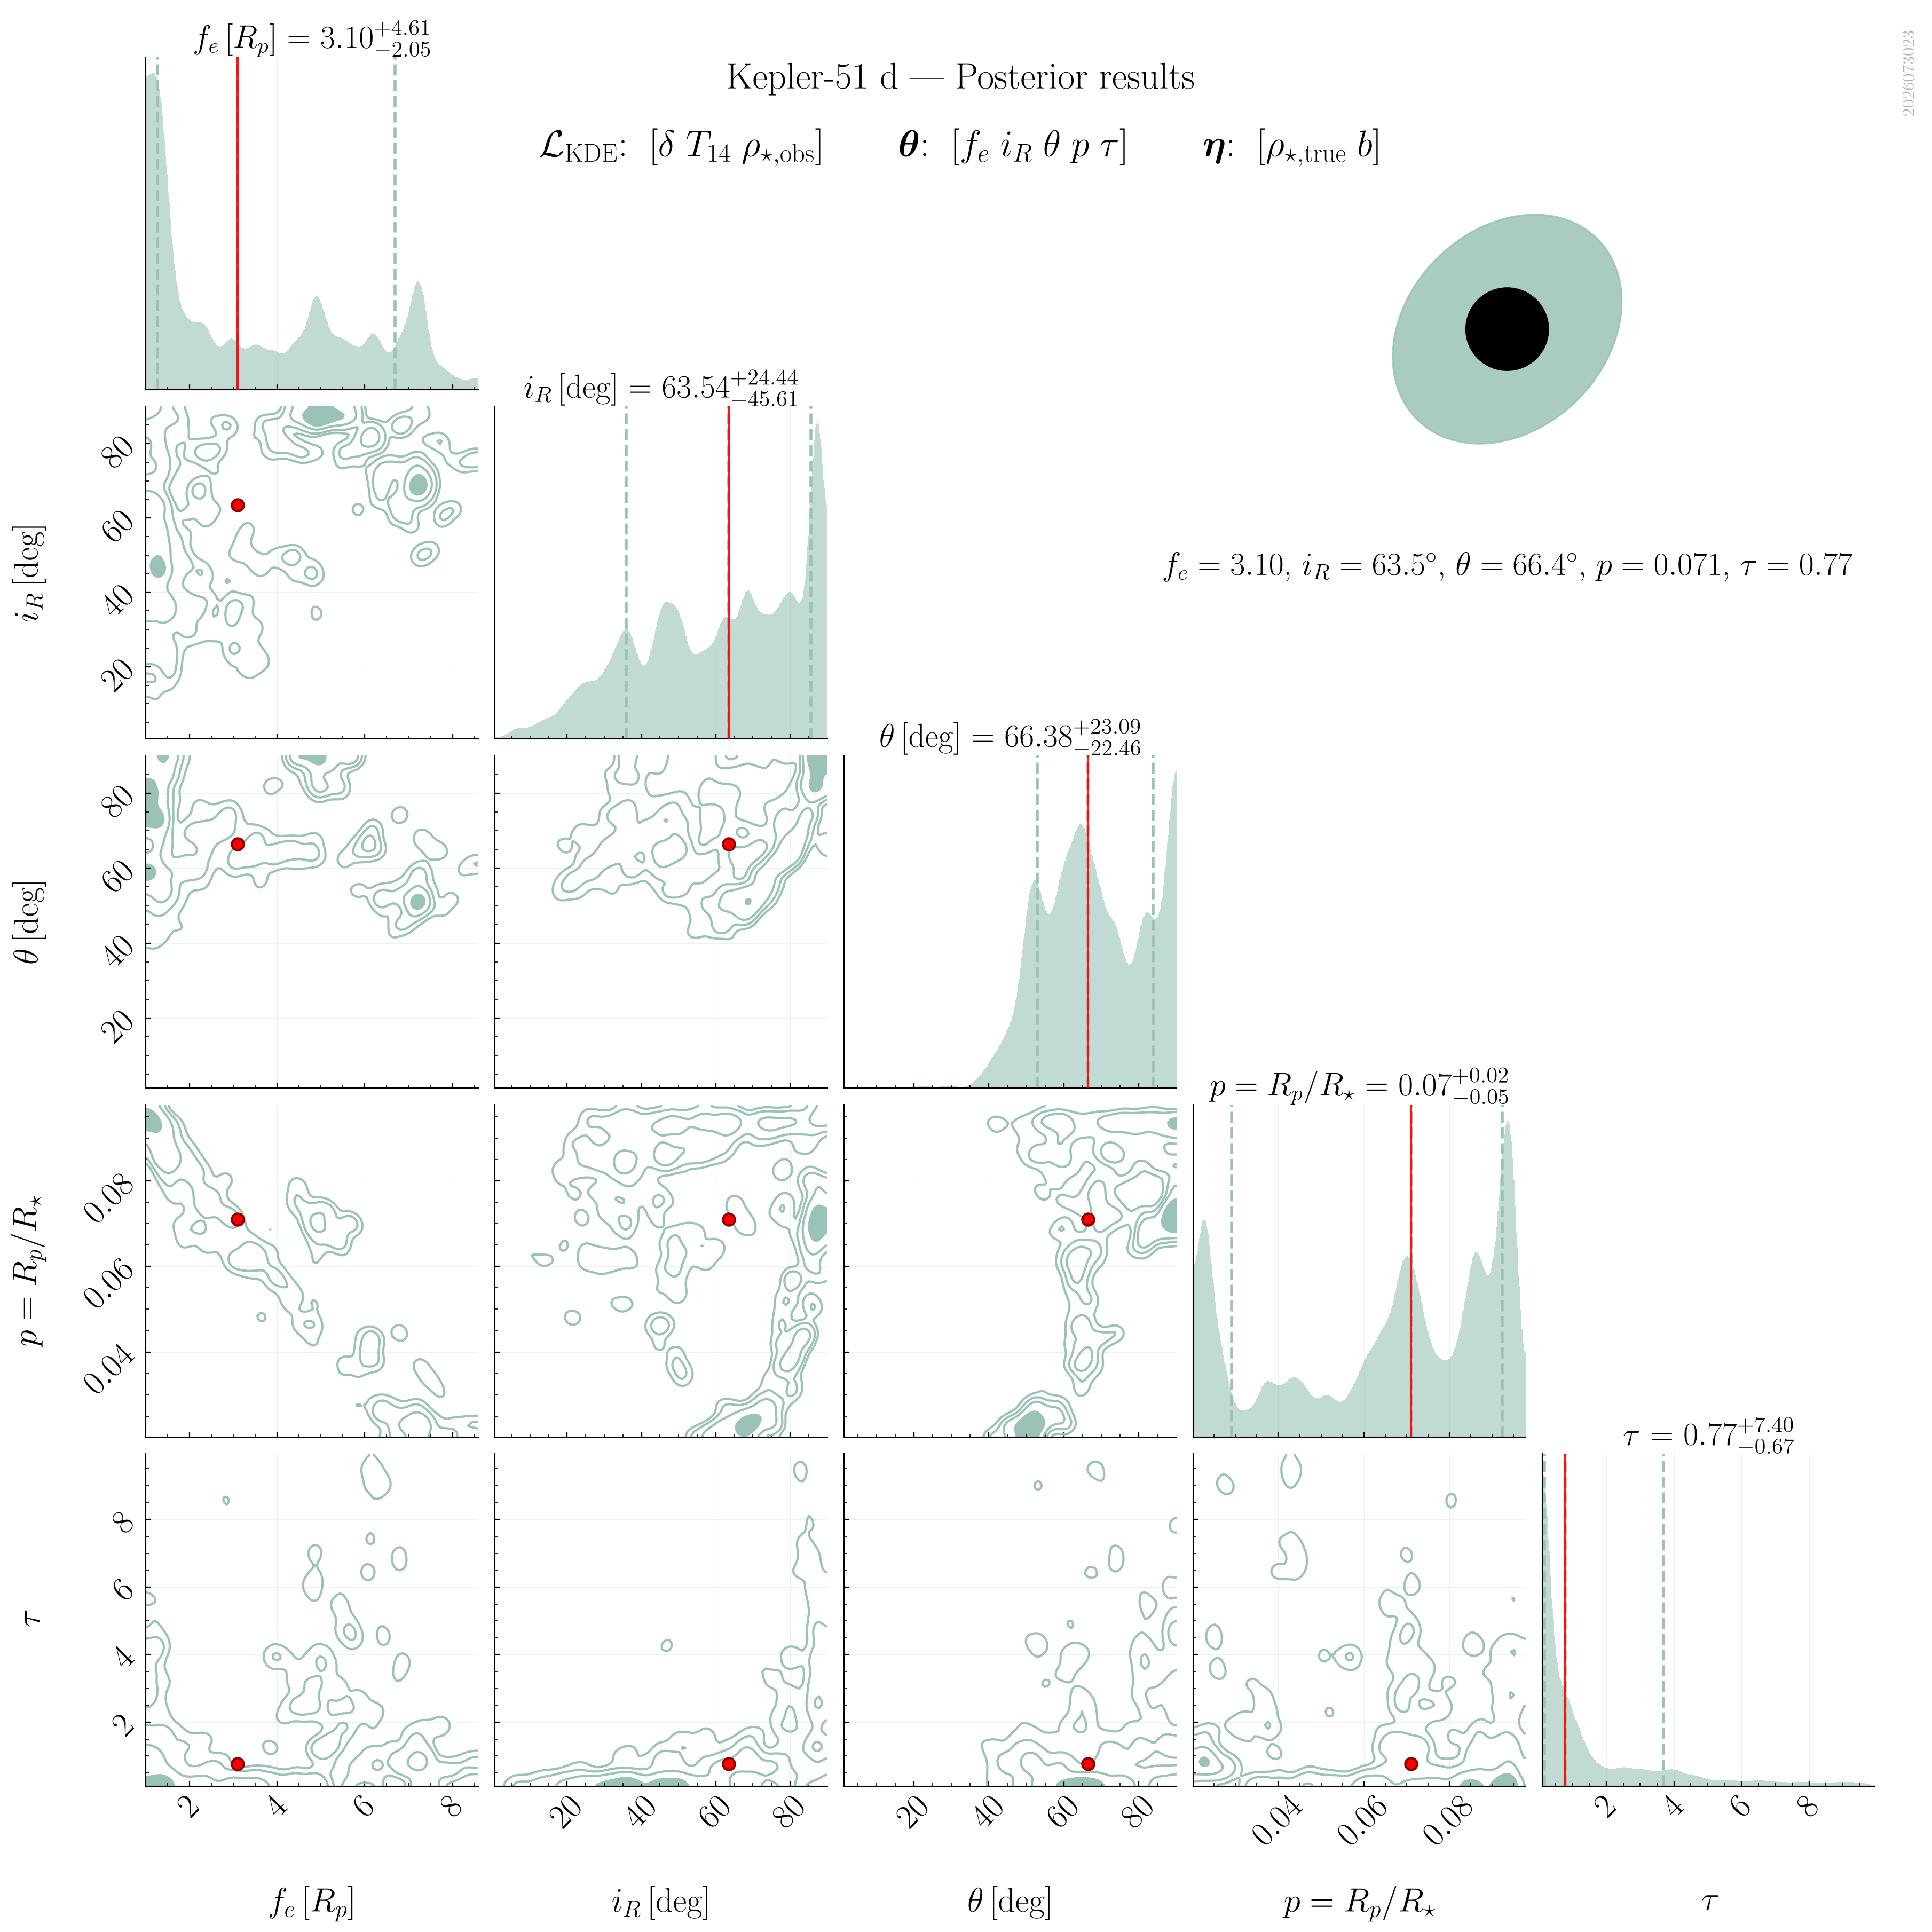

In [7]:
for pl in ['b', 'd']:
    fig_reduced = plot_results_panel_reduced_inset(runs[pl], paths, title=True)
    out_reduced = IMG / f"final_planet{pl}_panel_reduced.png"
    add_run_version_label(fig_reduced, RUN_VERSION)
    fig_reduced.savefig(out_reduced, bbox_inches="tight", dpi=200)
    print("->", out_reduced)
    plt.show()
